<h1><center>Customer Churn Analysis</center></h1>

In [55]:
# Import libraries
import pandas as pd
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score



In [ ]:
# Import dataset and view the first 5 rows.
ds = pd.read_csv('Churn_Modelling.csv')
ds.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


<h1><center>Visualizations</center></h1>

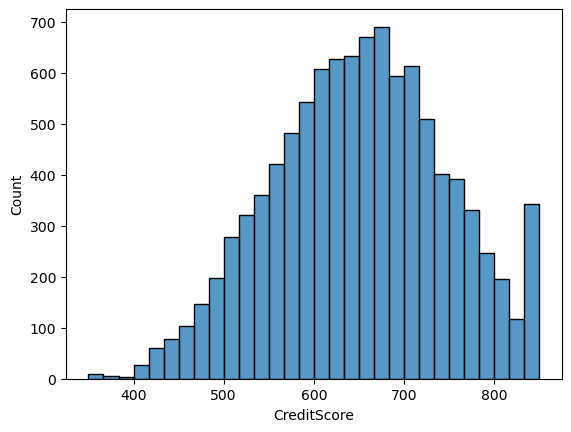

In [57]:
sns.histplot(data = ds, x = 'CreditScore', bins= 30)
plt.show()

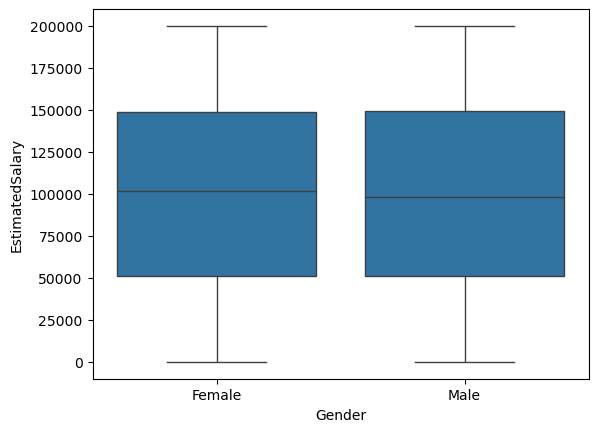

In [58]:
sns.boxplot(data = ds, x = 'Gender', y = 'EstimatedSalary')
plt.show()

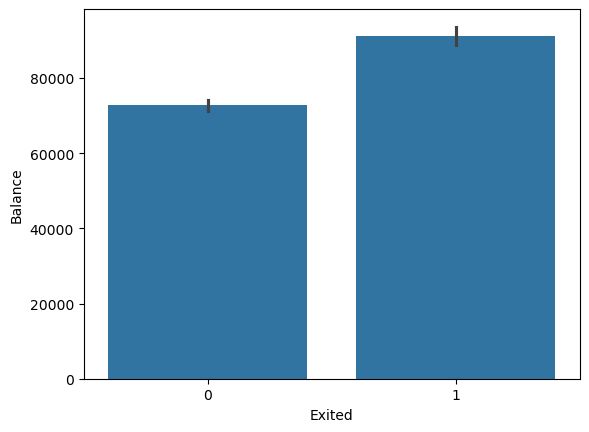

In [59]:
sns.barplot(data = ds, x = 'Exited', y = 'Balance')
plt.show()

<h1><center>Preprocessing Data</center></h1>

In [ ]:
# Split data to X and y series
X = ds.iloc[:, 3 :-1].values
y = ds.iloc[:, -1].values

In [ ]:
# View X series to ensure accuracy.
print(X)

[[619 'France' 'Female' ... 1 1 101348.88]
 [608 'Spain' 'Female' ... 0 1 112542.58]
 [502 'France' 'Female' ... 1 0 113931.57]
 ...
 [709 'France' 'Female' ... 0 1 42085.58]
 [772 'Germany' 'Male' ... 1 0 92888.52]
 [792 'France' 'Female' ... 1 0 38190.78]]


In [ ]:
# View y series to ensure accuracy
print(y)

[1 0 1 ... 1 1 0]


In [ ]:
# Apply label encoding to gender column.
le = LabelEncoder()
X[:, 2] = le.fit_transform(X[:, 2])

In [ ]:
# View data to ensure gender was recoded correctly.
print(X)

[[619 'France' 0 ... 1 1 101348.88]
 [608 'Spain' 0 ... 0 1 112542.58]
 [502 'France' 0 ... 1 0 113931.57]
 ...
 [709 'France' 0 ... 0 1 42085.58]
 [772 'Germany' 1 ... 1 0 92888.52]
 [792 'France' 0 ... 1 0 38190.78]]


In [ ]:
# Apply one-hot-encoding to location column.
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [1])], remainder = 'passthrough')
X = np.array(ct.fit_transform(X))

In [ ]:
# View series to ensure correct encoding.
print(X)

[[1.0 0.0 0.0 ... 1 1 101348.88]
 [0.0 0.0 1.0 ... 0 1 112542.58]
 [1.0 0.0 0.0 ... 1 0 113931.57]
 ...
 [1.0 0.0 0.0 ... 0 1 42085.58]
 [0.0 1.0 0.0 ... 1 0 92888.52]
 [1.0 0.0 0.0 ... 1 0 38190.78]]


In [ ]:
# Split data into training and testing sets
X_train, X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=0)

In [ ]:
# Apply standard scaler to X_train and X_test data.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

<h1><center>Create ANN</center></h1>

In [37]:
ann = tf.keras.models.Sequential()

In [36]:
ann.add(tf.keras.layers.Dense(units = 6, activation = 'relu'))


In [38]:
ann.add(tf.keras.layers.Dense(units = 6, activation = 'relu'))


In [39]:
ann.add(tf.keras.layers.Dense(units = 1, activation = 'sigmoid'))

In [41]:
ann.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [42]:
ann.fit(X_train,y_train, batch_size = 32, epochs=100)

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6279 - loss: 0.7233
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7812 - loss: 0.5134
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8134 - loss: 0.4563
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8126 - loss: 0.4383
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8121 - loss: 0.4331
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8109 - loss: 0.4313
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8106 - loss: 0.4306
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8095 - loss: 0.4307
Epoch 9/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8071 - loss: 0.4308
Epoch 10/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8089 - loss: 0.4305
Epoch 11/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8094 - loss: 0.4306
Epoch 12/100
250/250 ━━━━━━━━━━━━━━━━━━━━

In [44]:
print(ann.predict(scaler.transform([[1, 0, 0, 600, 1,40, 3,60000,2, 1, 1, 50000]]))>.50)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
[[ True]]


In [47]:
y_pred = ann.predict(X_test)
y_pred = (y_pred >.50)
print(np.concatenate((y_pred.reshape(len(y_pred), 1), y_test.reshape(len(y_test), 1)), 1))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
[[0 0]
 [0 1]
 [0 0]
 ...
 [0 0]
 [0 0]
 [0 0]]


In [54]:
cm = confusion_matrix(y_test, y_pred)
print(f" The confusion matrix result is:\n {cm}")
acc = accuracy_score(y_test, y_pred)
print(f"The accuracy score is: \n {acc}")

 The confusion matrix result is:
 [[1534   61]
 [ 323   82]]
The accuracy score is: 
 0.808
